In [1]:
!pip install wrds pandas matplotlib streamlit ipykernel

In [2]:
import wrds
import pandas as pd
db = wrds.Connection(
    wrds_username="Your WRDS user name",
    wrds_password="Your WRDS password"
)

Enter your WRDS username [Your WRDS user name]: haoxiadong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
import pandas as pd
import wrds

def download_financial_data(ticker="AAPL", start_year=2000, end_year=2025):
    db = wrds.Connection()

    sql_query = f"""
    SELECT 
        fyear, 
        tic, 
        at, 
        lt, 
        sale, 
        ni
    FROM comp.funda
    WHERE 
        tic = '{ticker}'
        AND fyear BETWEEN {start_year} AND {end_year}
        AND indfmt = 'INDL'
        AND datafmt = 'STD'
        AND consol = 'C'
    ORDER BY fyear ASC
    """

    df = db.raw_sql(sql_query)
    db.close()

    df['Total_Equity'] = df['at'] - df['lt']
    df['ROE'] = (df['ni'] / df['Total_Equity']).round(4)
    df['ROA'] = (df['ni'] / df['at']).round(4)
    df['Debt_to_Asset'] = (df['lt'] / df['at']).round(4)
    df['Net_Profit_Margin'] = (df['ni'] / df['sale']).round(4)
    df['Revenue_Growth_Rate'] = df['sale'].pct_change().round(4)

    df.to_csv("aapl.csv", index=False)
    print("✅ Data successfully saved as aapl.csv (Year 2000-2025)")

    return df

df_result = download_financial_data()

print(df_result)

Enter your WRDS username [dongchill]: haoxiadong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Data successfully saved as aapl.csv (Year 2000-2025)
    fyear   tic        at        lt      sale        ni  Total_Equity     ROE  \
0    2000  AAPL    6803.0    2696.0    7983.0     786.0        4107.0  0.1914   
1    2001  AAPL    6021.0    2101.0    5363.0     -25.0        3920.0 -0.0064   
2    2002  AAPL    6298.0    2203.0    5742.0      65.0        4095.0  0.0159   
3    2003  AAPL    6815.0    2592.0    6207.0      69.0        4223.0  0.0163   
4    2004  AAPL    8050.0    2974.0    8279.0     276.0        5076.0  0.0544   
5    2005  AAPL   11551.0    4085.0   13931.0    1335.0        7466.0  0.1788   
6    2006  AAPL   17205.0    7221.0   19315.0    1989.0        9984.0  0.1992   
7    2007  AAPL   25347.0   10815.0   24006.0    3496.0       14532.0  0.2406   
8    2008  AAPL   39572.0   18542.0   32479.0    4834.0       2103

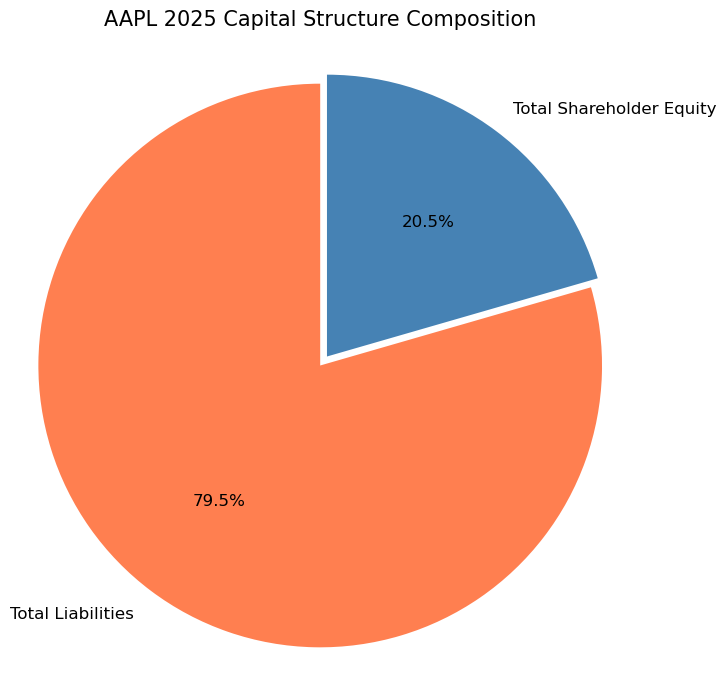

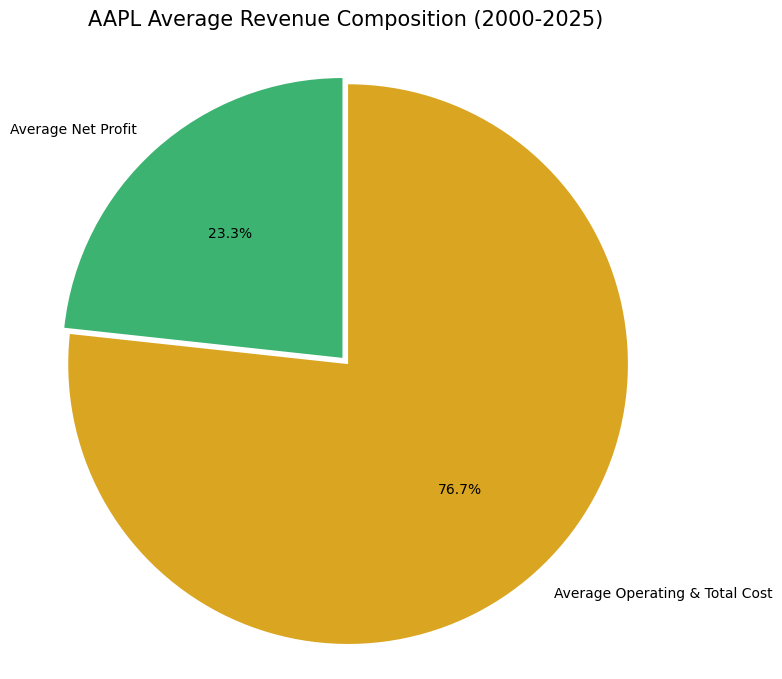

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("aapl.csv")

plt.style.use('default')

latest_year = df[df['fyear'] == 2025].iloc[0]

asset_labels = ['Total Liabilities', 'Total Shareholder Equity']
asset_sizes = [latest_year['lt'], latest_year['Total_Equity']]
colors = ['#ff7f50', '#4682b4']

plt.figure(figsize=(8, 8))
plt.pie(asset_sizes,
        labels=asset_labels,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=(0.02, 0.02),
        textprops={'fontsize': 12})
plt.title(f'AAPL 2025 Capital Structure Composition', fontsize=15, pad=20)
plt.axis('equal')
plt.show()


avg_revenue = df['sale'].mean()
avg_net_profit = df['ni'].mean()
avg_total_cost = avg_revenue - avg_net_profit

profit_labels = ['Average Net Profit', 'Average Operating & Total Cost']
profit_sizes = [avg_net_profit, avg_total_cost]

plt.figure(figsize=(8, 8))
plt.pie(profit_sizes,
        labels=profit_labels,
        autopct='%1.1f%%',
        colors=['#3cb371', '#daa520'],
        startangle=90,
        explode=(0.03, 0))
plt.title('AAPL Average Revenue Composition (2000-2025)', fontsize=15, pad=20)
plt.axis('equal')
plt.show()

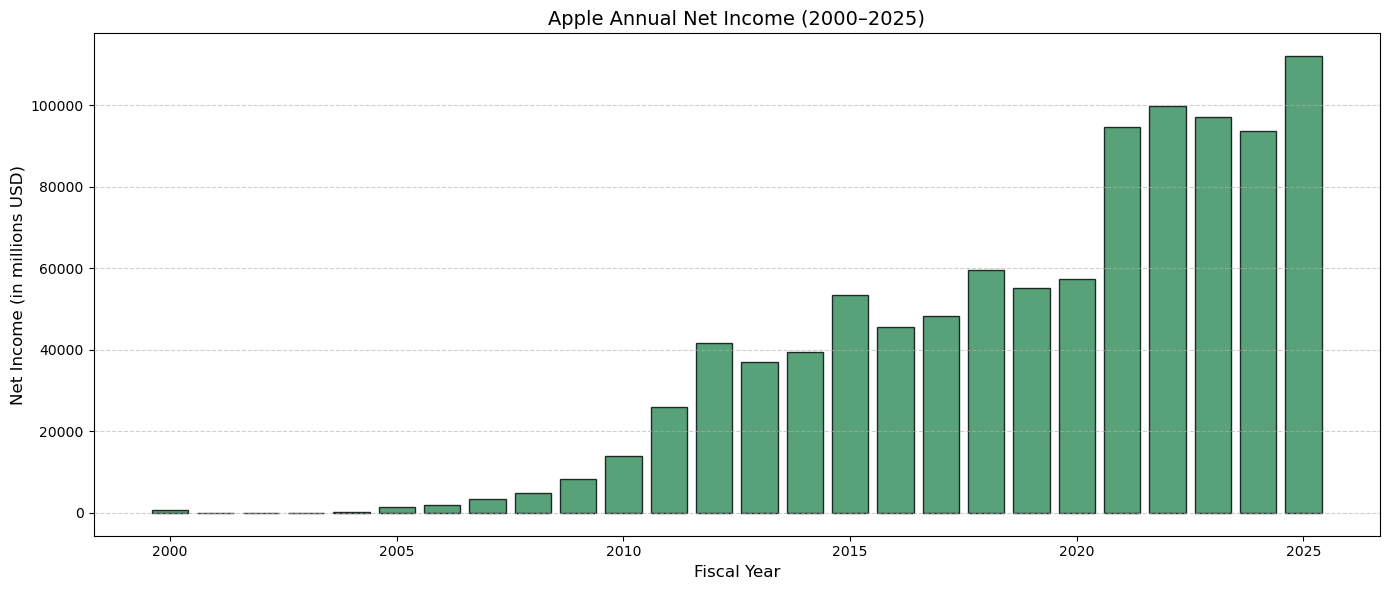

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("aapl.csv")

plt.figure(figsize=(14, 6))
plt.bar(
    df["fyear"],
    df["ni"],
    color="#2e8b57",
    edgecolor="black",
    alpha=0.8
)

plt.title("Apple Annual Net Income (2000–2025)", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=12)
plt.ylabel("Net Income (in millions USD)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()